In [38]:
import pandas as pd
df=pd.read_csv("Accidents.csv")

# Step-1 Initialization

print(df.shape)
print(df.head(5))
print(df.dtypes)
print(df.columns)
print(df.describe())

#Always check this step before going to another step




(3583, 13)
    Latitude   Longitude Weather     Light_Condition Road_Surface  \
0  36.862539 -121.615011    Rain            Daylight          Wet   
1  33.799881 -117.915311   Clear                Dusk          Dry   
2  33.619100 -117.885489   Clear      Dark - Lighted          Dry   
3  35.441225 -119.029861   Clear      Dark - Lighted          Dry   
4  35.196606 -119.545317   Clear  Dark - Not Lighted          Dry   

              Road_Function  Speed_Limit(MPH)  Day    Month             Hour  \
0  Other Principal Arterial              65.0   22  January    2:00pm-2:59pm   
1  Other Principal Arterial              35.0    5  January    5:00pm-5:59pm   
2  Other Principal Arterial              55.0   19  January  11:00pm-11:59pm   
3  Other Principal Arterial              40.0    4  January    8:00pm-8:59pm   
4            Minor Arterial              55.0    7  January  11:00pm-11:59pm   

   Number_of_Vehicles           Intersection  Fatalities  
0                   1    Not an In

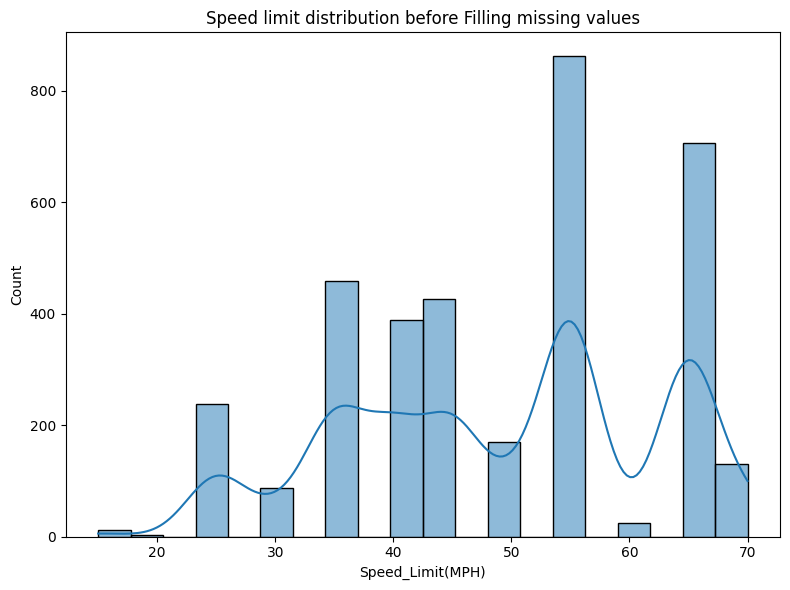

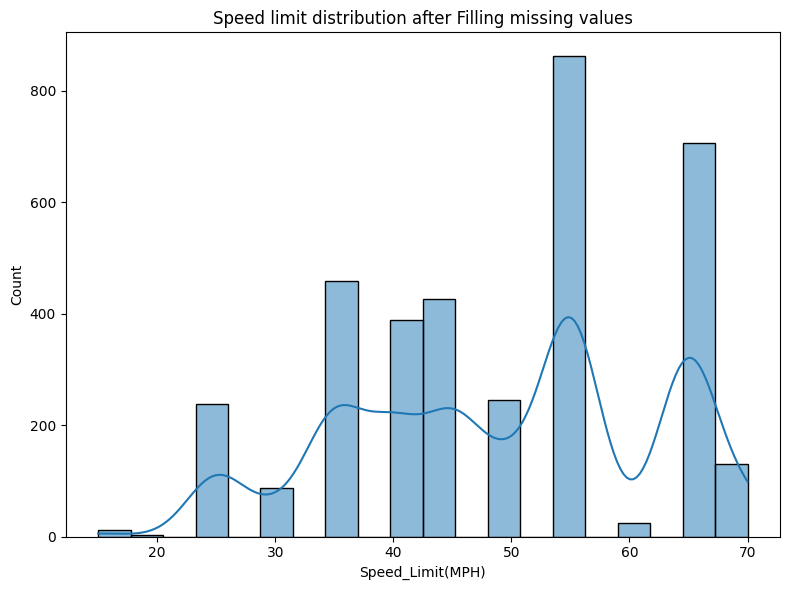

    Latitude   Longitude Weather     Light_Condition Road_Surface  \
0  36.862539 -121.615011    Rain            Daylight          Wet   
1  33.799881 -117.915311   Clear                Dusk          Dry   
2  33.619100 -117.885489   Clear      Dark - Lighted          Dry   
3  35.441225 -119.029861   Clear      Dark - Lighted          Dry   
4  35.196606 -119.545317   Clear  Dark - Not Lighted          Dry   

              Road_Function  Speed_Limit(MPH)  Day    Month             Hour  \
0  Other Principal Arterial              65.0   22  January    2:00pm-2:59pm   
1  Other Principal Arterial              35.0    5  January    5:00pm-5:59pm   
2  Other Principal Arterial              55.0   19  January  11:00pm-11:59pm   
3  Other Principal Arterial              40.0    4  January    8:00pm-8:59pm   
4            Minor Arterial              55.0    7  January  11:00pm-11:59pm   

   Number_of_Vehicles           Intersection  Fatalities  
0                   1    Not an Intersection 

In [39]:
#Step-2 Data cleaning

#2.1 Missing value check
df.isnull().sum()
#this means expect speed limit columns there are no as such null values or missing values.

#So we need to put mean value in the space area but before we do so i want to see the distribution first
col='Speed_Limit(MPH)'
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.figure(figsize=(8,6))
sns.histplot(df[col],kde= True,bins=20)
plt.title('Speed limit distribution before Filling missing values')
plt.xlabel('Speed_Limit(MPH)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('speed_limit_distribution.png', dpi=150)
plt.show()

#Now we want to fill the missing value and see the result 

missing_count=df[col].isna().sum()
mean_value=round(df[col].mean())
df[col] = df[col].fillna(mean_value)
df.isnull().sum()       #now it shows no null values in speed limit that means we have successfully fill the missing value in the blank space

plt.figure(figsize=(8,6))
sns.histplot(df[col],kde= True,bins=20)
plt.title('Speed limit distribution after Filling missing values')
plt.xlabel('Speed_Limit(MPH)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('speed_limit_distribution.png', dpi=150)
plt.show()
print(df.head())
df.isnull().sum()

#since we have just fill the 75 values out of around 3000 rows so that we donot see major difference in distribution but it is true that we have filled the missing values


2.2 #Droping unnecessary values

wrong_lat=df['Latitude'].round(2)==77.78
wrong_lon=df['Longitude'].round(2)==777.78
df = df[~(wrong_lat | wrong_lon)].copy()  #it means is the condition is true then it chnages into false and copy only the values that is legit and delete the unusual values
print(df.shape)  #now we can see the row is reduced by 2 beacuse the unusual value in row index 3157 and 3192 are deleted.

2.3 #Duplicate check

print(df.duplicated().sum())
df = df.drop_duplicates()  #there are no any duplicates vales in any rows 

2.4 #data types fixes
month_sort = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
df['Month'] = pd.Categorical(df['Month'], categories=month_sort, ordered=True)
print(df['Month'])  #it means the month has been sorted as well

2.4 #Now saved the cleaned file

df.to_csv("Accidents_cleaned_final.csv", index=False)









    Latitude   Longitude Weather     Light_Condition Road_Surface  \
0  36.862539 -121.615011    Rain            Daylight          Wet   
1  33.799881 -117.915311   Clear                Dusk          Dry   
2  33.619100 -117.885489   Clear      Dark - Lighted          Dry   
3  35.441225 -119.029861   Clear      Dark - Lighted          Dry   
4  35.196606 -119.545317   Clear  Dark - Not Lighted          Dry   

              Road_Function  Speed_Limit(MPH)  Day    Month             Hour  \
0  Other Principal Arterial              65.0   22  January    2:00pm-2:59pm   
1  Other Principal Arterial              35.0    5  January    5:00pm-5:59pm   
2  Other Principal Arterial              55.0   19  January  11:00pm-11:59pm   
3  Other Principal Arterial              40.0    4  January    8:00pm-8:59pm   
4            Minor Arterial              55.0    7  January  11:00pm-11:59pm   

   Number_of_Vehicles           Intersection  Fatalities  Hour_num  Hour_sin  \
0                   1   

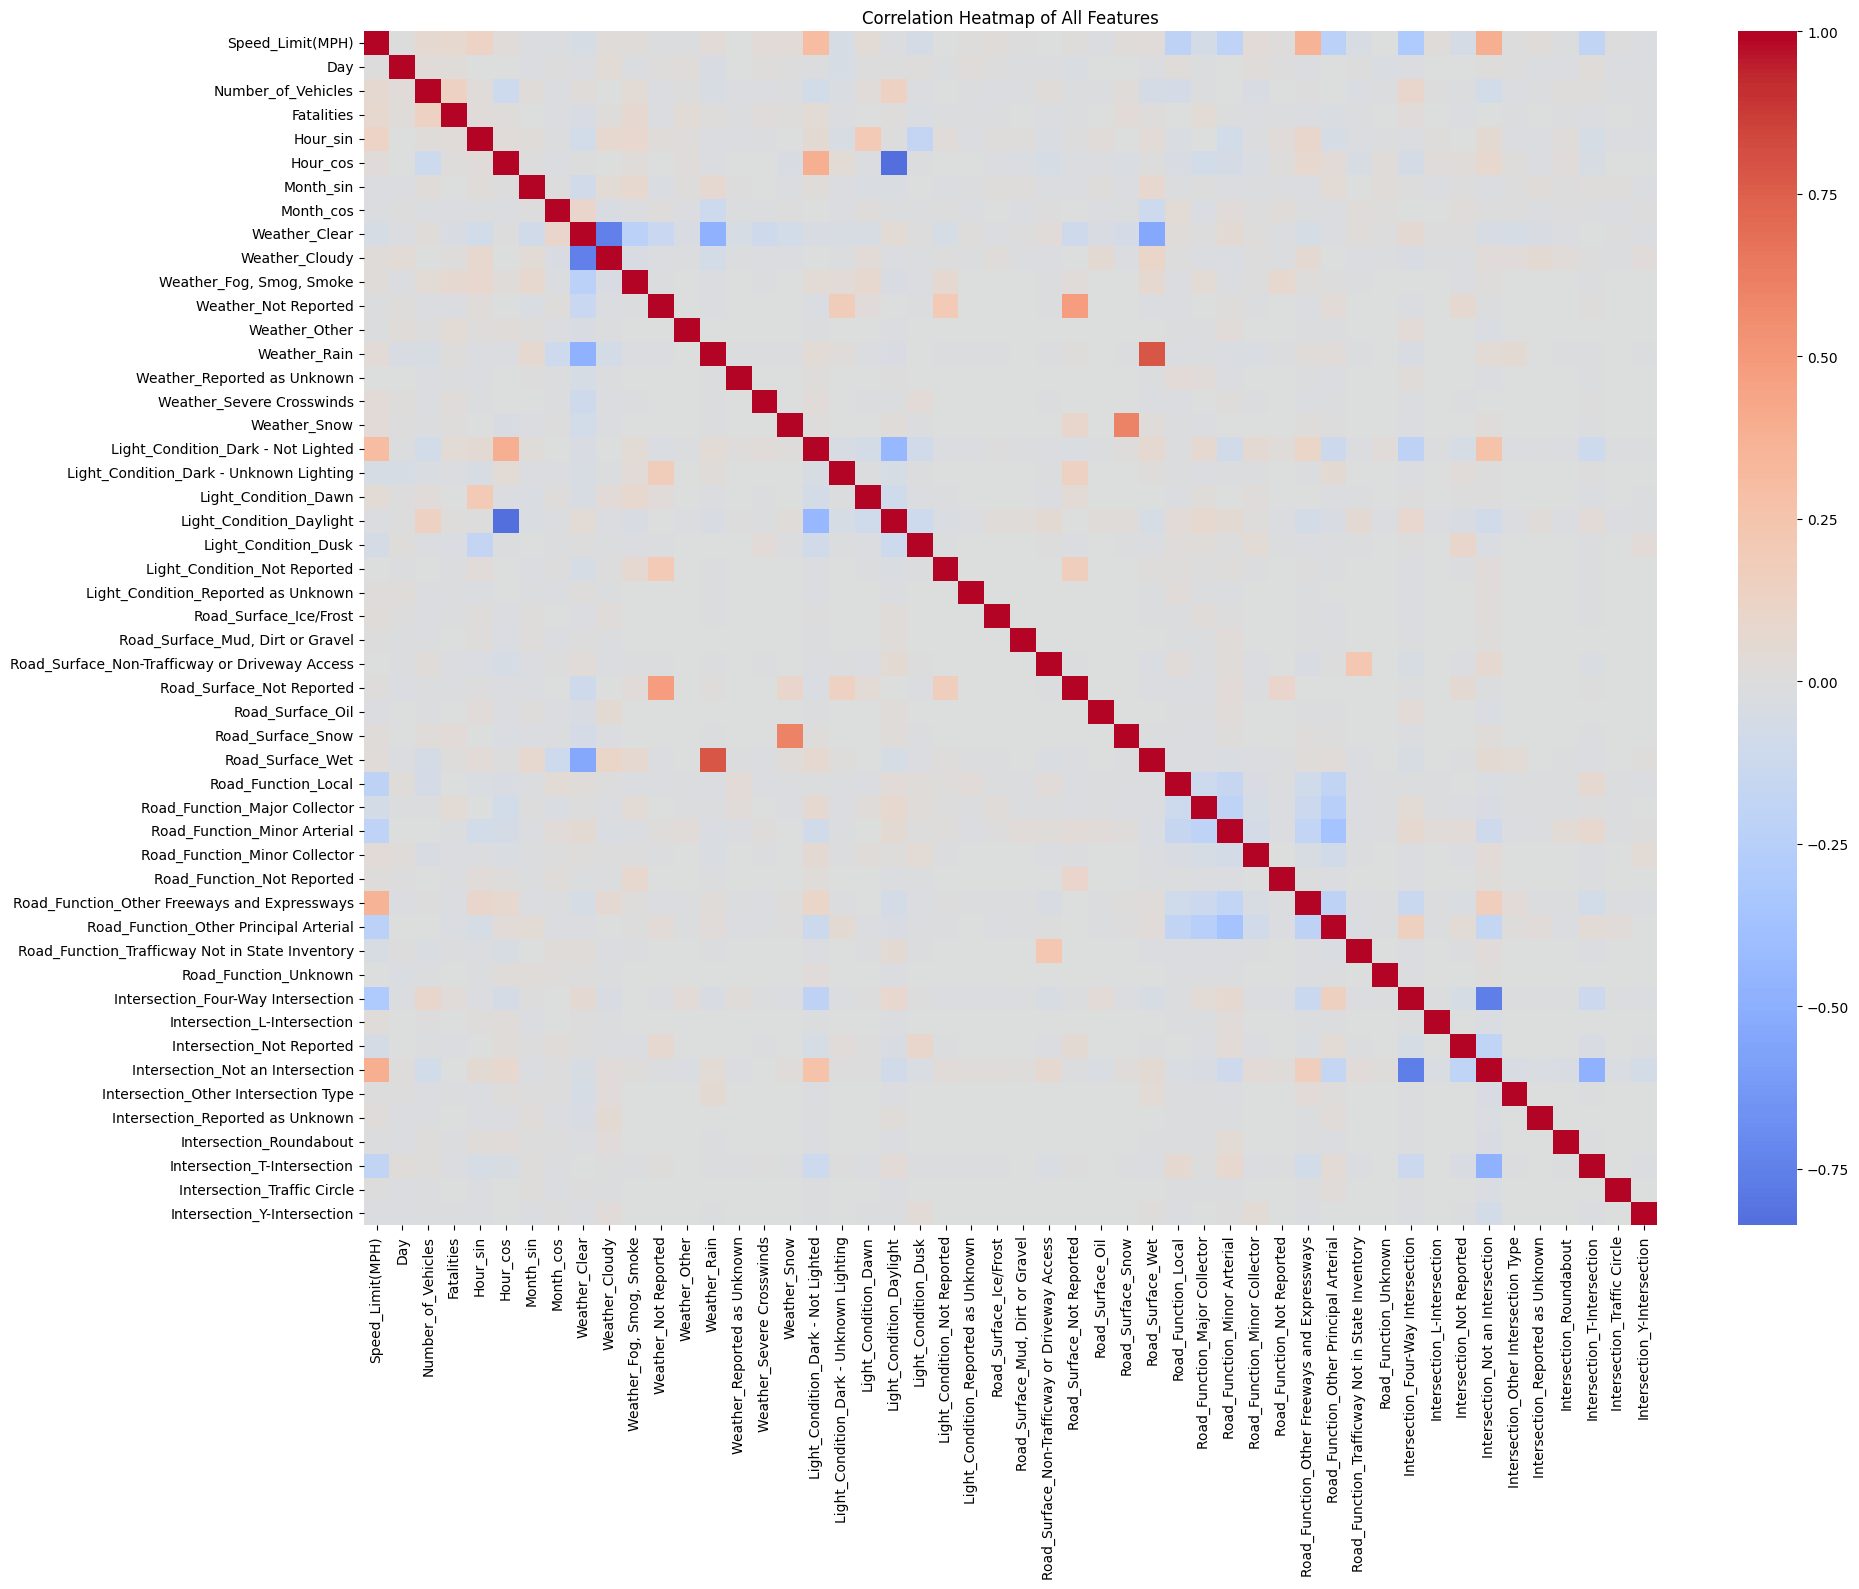

Speed_Limit(MPH)                                   1.000000
Intersection_Not an Intersection                   0.387283
Road_Function_Other Freeways and Expressways       0.366481
Light_Condition_Dark - Not Lighted                 0.297970
Hour_sin                                           0.125492
Fatalities                                         0.073701
Number_of_Vehicles                                 0.066645
Light_Condition_Dawn                               0.043364
Weather_Rain                                       0.036996
Weather_Snow                                       0.034969
Road_Function_Minor Collector                      0.032703
Weather_Severe Crosswinds                          0.031301
Hour_cos                                           0.029113
Road_Surface_Wet                                   0.026732
Weather_Fog, Smog, Smoke                           0.023758
Weather_Cloudy                                     0.023687
Road_Surface_Snow                       

In [40]:
#Step-4 Feature Engineering

4.1 #Cycling coding of Hour and Month
import numpy as np
import pandas as pd
df=pd.read_csv("Accidents_cleaned_final.csv")

# Extract starting hour as a number (handle 12am/12pm properly)
df['Hour_num'] = pd.to_datetime(df['Hour'].str.extract(r'^(\d+:\d+[ap]m)')[0], format='mixed').dt.hour

df['Hour_sin'] = np.sin(2*np.pi*df['Hour_num']/24)
df['Hour_cos'] = np.cos(2*np.pi*df['Hour_num']/24)


df['Month'] = pd.Categorical(df['Month'])
month_num = df['Month'].cat.codes + 1   # 1-12, since Month is already an ordered category
df['Month_sin'] = np.sin(2*np.pi*month_num/12)
df['Month_cos'] = np.cos(2*np.pi*month_num/12)

print(df.head())


4.2 #One hot coding
df = pd.get_dummies(df, columns=['Weather', 'Light_Condition', 'Road_Surface',
                                   'Road_Function', 'Intersection'],drop_first=True, dtype=int)
df.head()
print(df.columns)


4.3 #Drop those columns that you wonot feed into the model
model_df = df.drop(columns=['Latitude', 'Longitude', 'Hour', 'Month', 'Hour_num'])

model_df.head()

4.4 #Now we have to standarized the values 

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 16))
corr = model_df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()

target ="Speed_Limit(MPH)"  # replace with your actual target column
corr_with_target = model_df.corr(numeric_only=True)[target].sort_values(ascending=False)
print(corr_with_target)








In [41]:

#Step-5 Train-Test Split
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Drop rows where Hour_num failed to parse (and thus Hour_sin/Hour_cos are NaN)
model_df = model_df.dropna(subset=['Hour_sin', 'Hour_cos'])
print(model_df.shape)   # should show 3581 - 69 = 3512 rows

X=model_df.drop(['Speed_Limit(MPH)','Day', 'Hour_sin', 'Hour_cos','Month_sin','Month_cos'],axis=1)
y=model_df['Speed_Limit(MPH)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)




(3512, 50)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](44,)","[ 0.38, 1.89, -7.79,..., -9.34, 7.37,-11.4 ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](44,)","['Number_of_Vehicles','Fatalities','Weather_Clear',..., 'Intersection_T-Intersection','Intersection_Traffic Circle', 'Intersection_Y-Intersection']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,70.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,44
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,42


In [42]:
y_pred=model.predict(X_test)
y_pred

array([41.50062625, 63.07667048, 59.34117445, 45.32759667, 46.43676889,
       47.50842791, 49.24025655, 68.3037374 , 42.42516314, 38.29825013,
       46.05517681, 52.47992233, 58.95958237, 35.3458267 , 36.94629951,
       65.88015813, 62.11241329, 49.93032347, 67.15896114, 38.35661674,
       46.05517681, 54.38178189, 47.78871952, 36.41736148, 44.8470587 ,
       46.81836098, 48.85866446, 34.94908008, 48.32448406, 41.6767296 ,
       40.34563238, 47.78871952, 41.6767296 , 46.81836098, 37.15178825,
       64.35547349, 48.62691457, 48.85866446, 46.205019  , 67.15896114,
       66.49350011, 52.97020942, 38.1086979 , 36.62307403, 37.97502465,
       46.05517681, 34.06788862, 63.69001246, 47.52457884, 63.69001246,
       63.69001246, 45.82317926, 48.07954423, 42.51639107, 41.88221834,
       46.05517681, 42.70545475, 38.35661674, 41.7063388 , 47.78871952,
       42.82629188, 46.43676889, 48.1703116 , 47.12683582, 59.34117445,
       47.50842791, 65.11865766, 43.08704683, 47.55696962, 41.35

In [43]:
y_test


510     25.0
1624    55.0
2370    65.0
1506    45.0
2834    55.0
        ... 
1235    55.0
1784    55.0
234     45.0
570     40.0
2926    65.0
Name: Speed_Limit(MPH), Length: 703, dtype: float64

In [44]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
r2=r2_score(y_test,y_pred)
rmse=mean_squared_error(y_test,y_pred)**0.5
print(f"RMSE: {rmse:.2f}")
r2  #r2 is low beacuse of obvious reason the Fatalities parameter is very same so that the model cannot be trained to be unique thats why it is showing low r2 value

RMSE: 8.81


0.4890790783487664

In [45]:
n = X_test.shape[0]
p = X_test.shape[1] 

# common use: adjusted R² needs n and p
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
adj_r2

0.45491415349670816

In [46]:
import joblib

joblib.dump(model, 'speed_limit_model.pkl')

['speed_limit_model.pkl']

In [47]:
model_df.columns

Index(['Speed_Limit(MPH)', 'Day', 'Number_of_Vehicles', 'Fatalities',
       'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Weather_Clear',
       'Weather_Cloudy', 'Weather_Fog, Smog, Smoke', 'Weather_Not Reported',
       'Weather_Other', 'Weather_Rain', 'Weather_Reported as Unknown',
       'Weather_Severe Crosswinds', 'Weather_Snow',
       'Light_Condition_Dark - Not Lighted',
       'Light_Condition_Dark - Unknown Lighting', 'Light_Condition_Dawn',
       'Light_Condition_Daylight', 'Light_Condition_Dusk',
       'Light_Condition_Not Reported', 'Light_Condition_Reported as Unknown',
       'Road_Surface_Ice/Frost', 'Road_Surface_Mud, Dirt or Gravel',
       'Road_Surface_Non-Trafficway or Driveway Access',
       'Road_Surface_Not Reported', 'Road_Surface_Oil', 'Road_Surface_Snow',
       'Road_Surface_Wet', 'Road_Function_Local',
       'Road_Function_Major Collector', 'Road_Function_Minor Arterial',
       'Road_Function_Minor Collector', 'Road_Function_Not Reported',
     

In [48]:
import pandas as pd
import joblib

# ---- Load model ----
model = joblib.load('speed_limit_model.pkl')

def predict_speed_limit(model, numeric_values: dict, category_values: dict) -> float:
    row = pd.DataFrame(0, index=[0], columns=model.feature_names_in_)
    all_inputs = {**numeric_values, **category_values}
    unknown_cols = set(all_inputs) - set(model.feature_names_in_)
    if unknown_cols:
        raise ValueError(f"Unknown column name(s), check spelling: {unknown_cols}")
    for col, val in all_inputs.items():
        row[col] = val
    return model.predict(row)[0]

# ---- EDIT THESE VALUES for whichever road you want to check ----
numeric_values = {
    'Number_of_Vehicles':4,
    'Fatalities':0,
}

category_values = {
    'Weather_Rain': 1,
    'Light_Condition_Dawn': 1,
    'Road_Surface_Wet': 1,
    'Road_Function_Local': 1,
    'Intersection_L-Intersection': 1,
}

# ---- Predict ----
predicted_speed = predict_speed_limit(model, numeric_values, category_values)
print(f"Predicted speed limit: {predicted_speed:.1f} MPH")

Predicted speed limit: 65.6 MPH


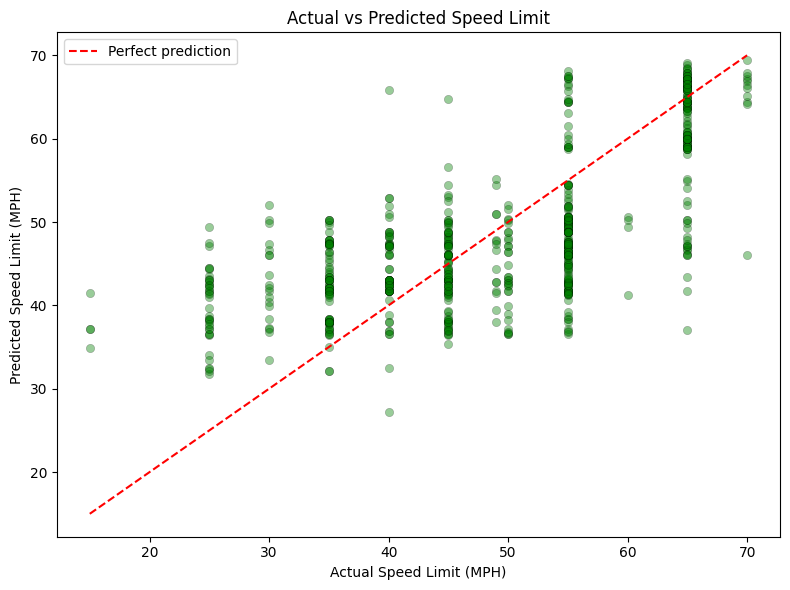

In [54]:
import matplotlib.pyplot as plt

# y_test = actual speed limits, y_pred = model's predicted speed limits
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4, color='green', edgecolor='k', linewidth=0.3)

# Diagonal reference line: perfect predictions would fall exactly on this line
min_val = min(y_test.min(), y_pred.min())  #Finds the smallest value across both actual and predicted speed limits needed to know where the diagonal line should start.
max_val = max(y_test.max(), y_pred.max())  #Finds the largest value across both where the diagonal line should end.
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect prediction')  #Draws a straight diagonal line from min_val to max_val


plt.xlabel('Actual Speed Limit (MPH)')
plt.ylabel('Predicted Speed Limit (MPH)')
plt.title('Actual vs Predicted Speed Limit')
plt.legend()
plt.tight_layout()

# Save it so you can use it on LinkedIn/README
plt.savefig('actual_vs_predicted_speed_limit.png', dpi=150)
plt.show()